In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv("Downloads/payment_failures_multiclass.csv")

In [3]:
df.head()

,txn_id,user_id,merchant_id,payment_method,amount,merchant_category,is_international,payer_bank,payee_bank,issuer_type,...,available_balance_est,velocity_score,risk_score,geo_distance_km_from_usual,txn_hour,day_of_week,is_night_txn,merchant_failure_rate_1h,bank_failure_rate_1h,failure_reason
0,T1000000,61646,5244,UPI,56.80,BILLS,0,ICICI,SBI,PUBLIC,...,356.28,30.3,0.3,8.79,10,2,0,0.0816,0.0384,MERCHANT_CONFIGURATION_ISSUE
1,T1000001,37475,2649,UPI,145.74,BILLS,0,ICICI,SBI,PRIVATE,...,486.26,34.2,29.3,9.27,15,6,0,0.0416,0.0120,INSUFFICIENT_FUNDS
2,T1000002,92086,6755,UPI,364.05,ECOM,0,HDFC,IDFC,PRIVATE,...,125.83,63.9,20.0,2.50,0,1,1,0.0165,0.0213,INSUFFICIENT_FUNDS
3,T1000003,57891,3227,UPI,75.31,TRAVEL,0,SBI,KOTAK,PRIVATE,...,117.73,22.4,11.9,7.88,11,4,0,0.0328,0.0882,BANK_SERVER_DOWN
4,T1000004,18513,7786,UPI,91.36,FUEL,0,PNB,KOTAK,COOP,...,189.28,52.3,20.2,3.22,0,5,1,0.0570,0.0107,INSUFFICIENT_FUNDS


In [4]:
df.tail()

,txn_id,user_id,merchant_id,payment_method,amount,merchant_category,is_international,payer_bank,payee_bank,issuer_type,...,available_balance_est,velocity_score,risk_score,geo_distance_km_from_usual,txn_hour,day_of_week,is_night_txn,merchant_failure_rate_1h,bank_failure_rate_1h,failure_reason
24995,T1024995,94975,9599,WALLET,392.93,FOOD,0,AXIS,HDFC,PRIVATE,...,89.62,42.2,4.3,6.85,2,2,1,0.1015,0.0085,INSUFFICIENT_FUNDS
24996,T1024996,84346,7871,WALLET,43.62,FOOD,0,ICICI,IDFC,PRIVATE,...,651.07,5.1,33.9,28.31,10,1,0,0.0153,0.0152,PIN_OR_OTP_FAILED
24997,T1024997,87245,4017,WALLET,396.36,TRAVEL,0,KOTAK,ICICI,PUBLIC,...,333.18,41.1,24.1,3.27,13,3,0,0.0181,0.0556,INSUFFICIENT_FUNDS
24998,T1024998,62215,1685,WALLET,204.88,GROCERY,0,HDFC,BOB,PRIVATE,...,64.31,16.9,22.3,18.62,16,6,0,0.0419,0.0592,INSUFFICIENT_FUNDS
24999,T1024999,58520,6722,UPI,270.88,FUEL,0,IDFC,BOB,COOP,...,214.66,18.8,20.2,2.96,12,2,0,0.0106,0.0430,INSUFFICIENT_FUNDS


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   txn_id                      25000 non-null  object 
 1   user_id                     25000 non-null  int64  
 2   merchant_id                 25000 non-null  int64  
 3   payment_method              25000 non-null  object 
 4   amount                      25000 non-null  float64
 5   merchant_category           25000 non-null  object 
 6   is_international            25000 non-null  int64  
 7   payer_bank                  25000 non-null  object 
 8   payee_bank                  25000 non-null  object 
 9   issuer_type                 25000 non-null  object 
 10  device_type                 25000 non-null  object 
 11  os_version_major            25000 non-null  int64  
 12  app_version_major           25000 non-null  int64  
 13  is_rooted_or_jailbroken     250

In [6]:
df.describe()

,user_id,merchant_id,amount,is_international,os_version_major,app_version_major,is_rooted_or_jailbroken,latency_ms,packet_loss_pct,signal_strength_dbm,...,daily_limit_remaining,available_balance_est,velocity_score,risk_score,geo_distance_km_from_usual,txn_hour,day_of_week,is_night_txn,merchant_failure_rate_1h,bank_failure_rate_1h
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,...,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000
mean,54931.111560,5471.492040,208.588582,0.018640,11.19328,11.496360,0.049240,132.00076,1.459400,-85.671320,...,46403.099839,346.854589,36.535336,21.573308,6.093216,11.38364,3.004960,0.378560,0.047595,0.051800
std,25944.479021,2599.157495,164.958573,0.135253,3.24146,2.992742,0.216373,73.72831,1.079037,10.365141,...,10539.268932,327.983667,14.677885,11.270724,8.214253,6.90984,1.994205,0.485038,0.037181,0.039936
min,10001.000000,1000.000000,10.000000,0.000000,0.00000,3.000000,0.000000,20.00000,0.000000,-120.000000,...,0.000000,0.000000,0.000000,0.000000,0.090000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,32628.000000,3200.750000,101.190000,0.000000,9.00000,9.000000,0.000000,78.00000,0.660000,-93.000000,...,39245.497500,146.647500,26.400000,13.900000,1.890000,5.00000,1.000000,0.000000,0.019600,0.022100
50%,54869.000000,5454.000000,163.270000,0.000000,12.00000,12.000000,0.000000,122.00000,1.200000,-86.000000,...,47290.830000,251.935000,36.100000,20.100000,3.680000,11.00000,3.000000,0.000000,0.038700,0.041900
75%,77545.500000,7745.000000,261.612500,0.000000,13.00000,14.000000,0.000000,175.00000,1.990000,-79.000000,...,55365.185000,437.132500,46.300000,27.500000,7.170000,17.00000,5.000000,1.000000,0.065700,0.071200
max,99992.000000,9998.000000,2827.440000,1.000000,17.00000,20.000000,1.000000,525.00000,10.000000,-50.000000,...,60000.000000,5618.210000,97.900000,93.000000,282.710000,23.00000,6.000000,1.000000,0.279300,0.355400


In [7]:
df.isnull().sum()

txn_id                        0
user_id                       0
merchant_id                   0
payment_method                0
amount                        0
merchant_category             0
is_international              0
payer_bank                    0
payee_bank                    0
issuer_type                   0
device_type                   0
os_version_major              0
app_version_major             0
is_rooted_or_jailbroken       0
sim_operator                  0
network_type                  0
latency_ms                    0
packet_loss_pct               0
signal_strength_dbm           0
avg_txn_amount_30d            0
txn_count_24h                 0
failed_txn_count_1h           0
chargeback_flag_180d          0
account_age_days              0
daily_limit_remaining         0
available_balance_est         0
velocity_score                0
risk_score                    0
geo_distance_km_from_usual    0
txn_hour                      0
day_of_week                   0
is_night

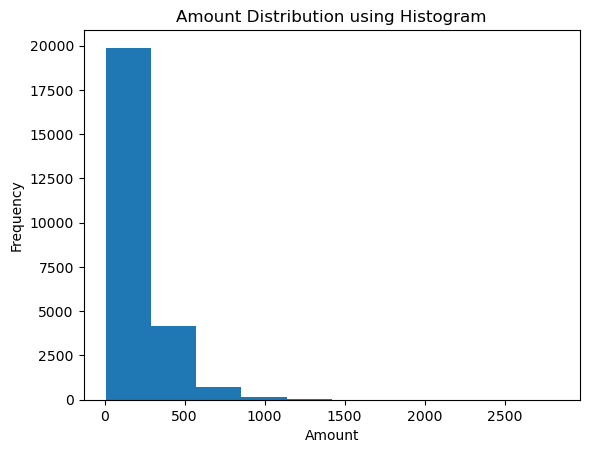

In [8]:
plt.hist(df["amount"])
plt.title("Amount Distribution using Histogram")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

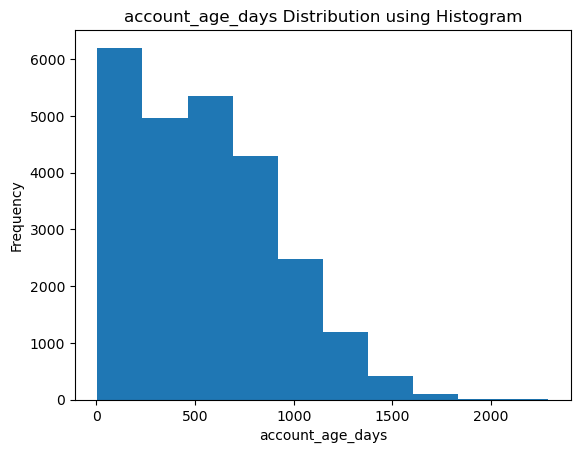

In [9]:
plt.hist(df["account_age_days"])
plt.title("account_age_days Distribution using Histogram")
plt.xlabel("account_age_days")
plt.ylabel("Frequency")
plt.show()

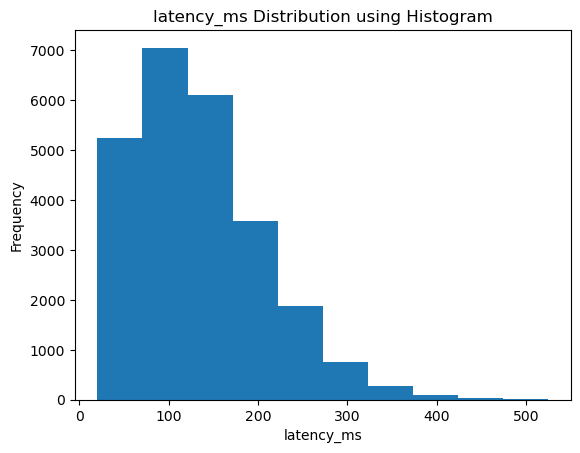

In [10]:
plt.hist(df["latency_ms"])
plt.title("latency_ms Distribution using Histogram")
plt.xlabel("latency_ms")
plt.ylabel("Frequency")
plt.show()

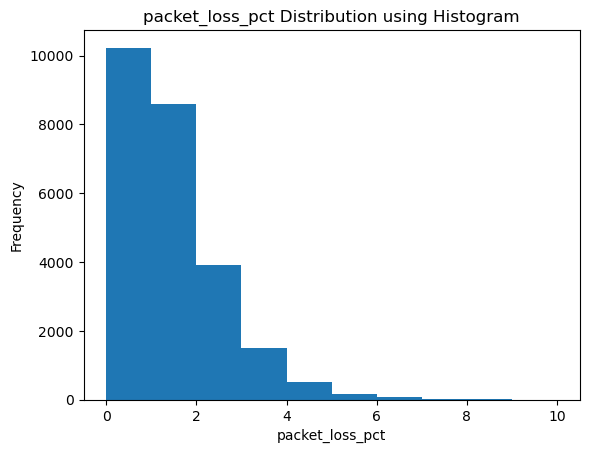

In [11]:
plt.hist(df["packet_loss_pct"])
plt.title("packet_loss_pct Distribution using Histogram")
plt.xlabel("packet_loss_pct")
plt.ylabel("Frequency")
plt.show()

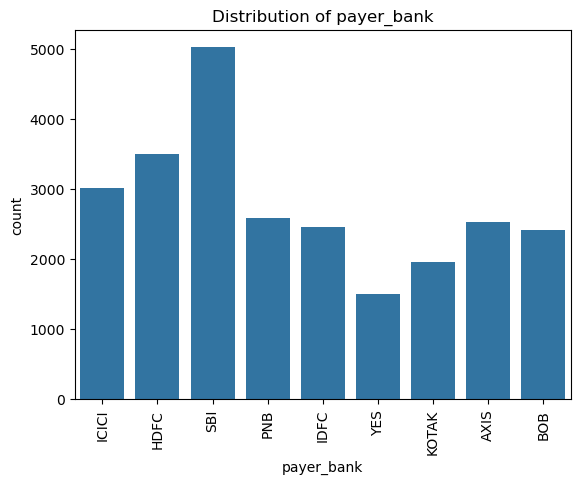

In [14]:
sns.countplot(x='payer_bank', data=df)
plt.title("Distribution of payer_bank")
plt.xticks(rotation=90)
plt.show()

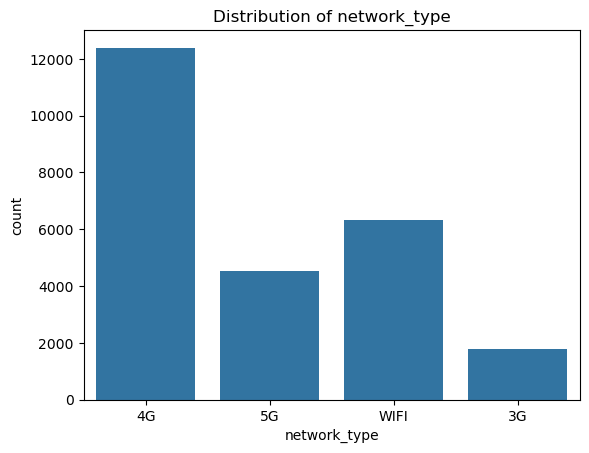

In [16]:
sns.countplot(x='network_type', data=df)
plt.title("Distribution of network_type")
plt.show()

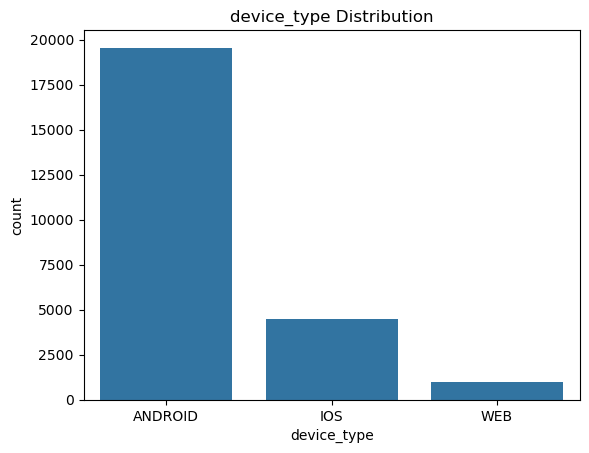

In [17]:
sns.countplot(x='device_type', data=df)
plt.title("device_type Distribution")
plt.show()

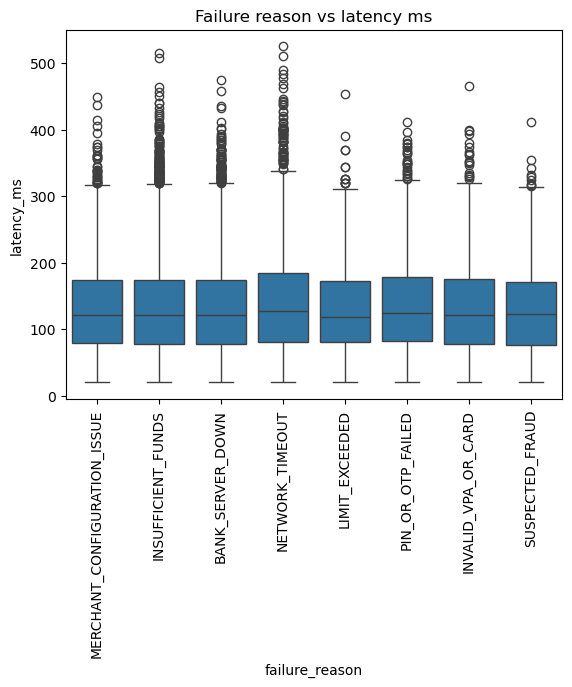

In [18]:
sns.boxplot(x='failure_reason', y='latency_ms', data=df)
plt.title("Failure reason vs latency ms")
plt.xticks(rotation=90)
plt.show()

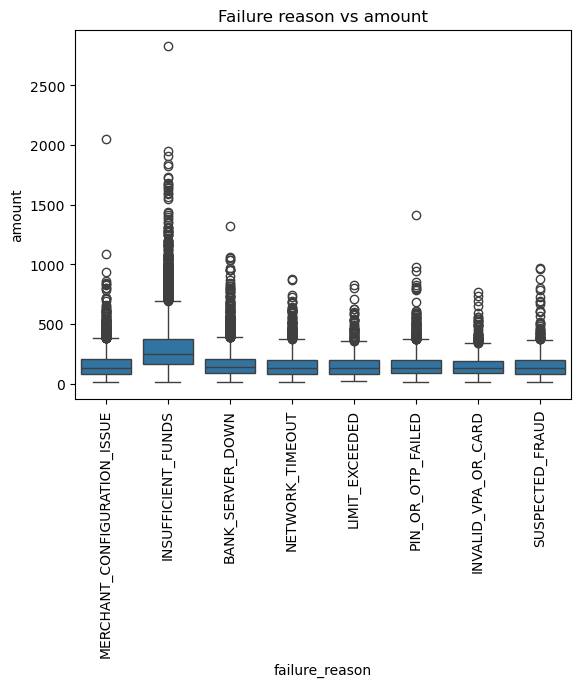

In [20]:
sns.boxplot(x='failure_reason', y='amount', data=df)
plt.title("Failure reason vs amount")
plt.xticks(rotation=90)
plt.show()

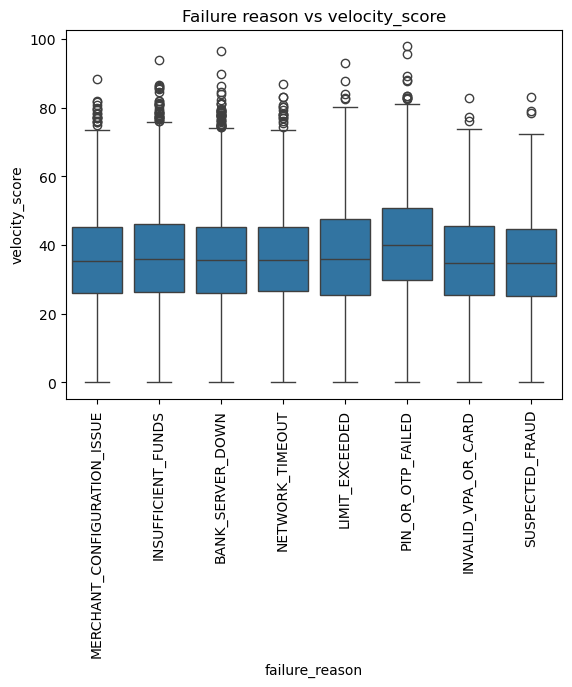

In [21]:
sns.boxplot(x='failure_reason', y='velocity_score', data=df)
plt.title("Failure reason vs velocity_score")
plt.xticks(rotation=90)
plt.show()

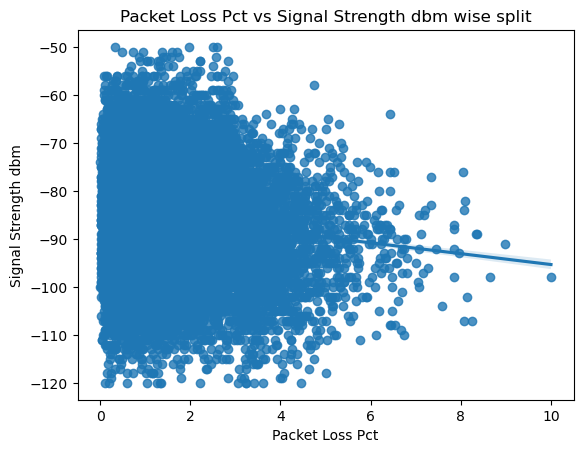

In [22]:
sns.regplot(x="packet_loss_pct",y="signal_strength_dbm",data=df)
plt.title("Packet Loss Pct vs Signal Strength dbm wise split")
plt.xlabel("Packet Loss Pct")
plt.ylabel("Signal Strength dbm")
plt.show()

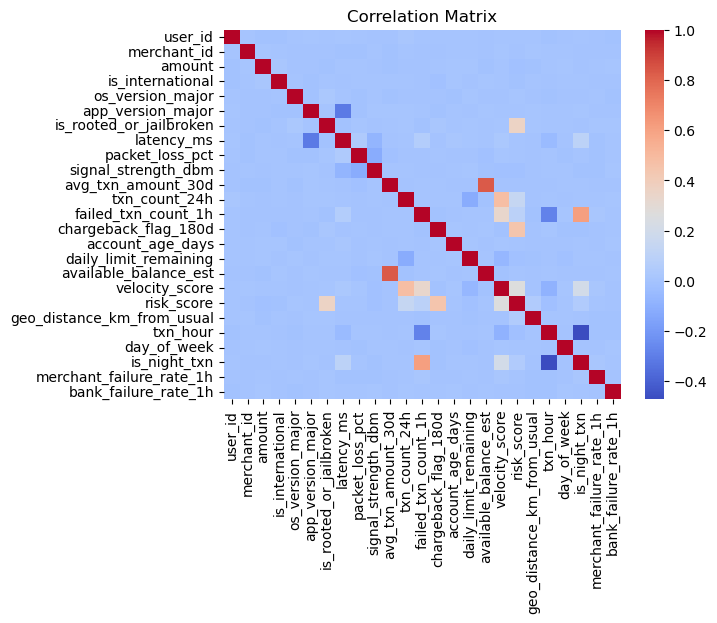

In [25]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [4]:
df['is_weekend'] = df['day_of_week'].isin(['Saturday','Sunday']).astype(int)

df['time_category'] = pd.cut(df['txn_hour'],
                            bins=[0,6,12,18,24],
                            labels=['Night','Morning','Afternoon','Evening'])

df['is_peak_hour'] = df['txn_hour'].between(18,22).astype(int)

In [9]:
df['failure_rate_1h'] = df['failed_txn_count_1h'] / (df['txn_count_24h'] + 1)
df['avg_txn_per_hour'] = df['txn_count_24h'] / 24

In [8]:
df['log_amount'] = np.log1p(df['amount'])
df['log_latency'] = np.log1p(df['latency_ms'])

In [7]:
df['risk_amount_interaction'] = df['risk_score'] * df['amount']
df['network_issue_score'] = df['latency_ms'] * df['packet_loss_pct']

In [11]:
from sklearn.preprocessing import LabelEncoder

In [12]:
categorical_columns = [
    'payment_method',
    'device_type',
    'merchant_category',
    'payer_bank',
    'payee_bank',
    'issuer_type',
    'sim_operator',
    'network_type'
]
for col in categorical_columns:
    le = LabelEncoder()  
    df[col] = le.fit_transform(df[col])

In [13]:
df['failure_reason'] = le.fit_transform(df['failure_reason'])

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()
num_cols = ['amount','latency_ms','risk_score','available_balance_est']
df[num_cols] = scaler.fit_transform(df[num_cols])

In [16]:
df = df.drop(['txn_id','time_category', 'user_id', 'merchant_id'], axis=1)

In [8]:
from sklearn.model_selection import train_test_split
x = df.drop('failure_reason', axis=1)
y = df['failure_reason']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Traning set size:", x_train.shape)   
print("Test set size:", x_test.shape)
print("cheating_risk distribution in Train:\n", y_train.value_counts(normalize=True))
print("sheating_risk distribution in Test:\n", y_test.value_counts(normalize=True))

Traning set size: (20000, 34)
Test set size: (5000, 34)
cheating_risk distribution in Train:
 failure_reason
INSUFFICIENT_FUNDS              0.34395
BANK_SERVER_DOWN                0.20545
MERCHANT_CONFIGURATION_ISSUE    0.13165
PIN_OR_OTP_FAILED               0.10100
NETWORK_TIMEOUT                 0.07820
INVALID_VPA_OR_CARD             0.05275
LIMIT_EXCEEDED                  0.04500
SUSPECTED_FRAUD                 0.04200
Name: proportion, dtype: float64
sheating_risk distribution in Test:
 failure_reason
INSUFFICIENT_FUNDS              0.3440
BANK_SERVER_DOWN                0.2054
MERCHANT_CONFIGURATION_ISSUE    0.1316
PIN_OR_OTP_FAILED               0.1010
NETWORK_TIMEOUT                 0.0782
INVALID_VPA_OR_CARD             0.0528
LIMIT_EXCEEDED                  0.0450
SUSPECTED_FRAUD                 0.0420
Name: proportion, dtype: float64


In [13]:
df.select_dtypes(include='object').columns
df = df.select_dtypes(exclude=['object'])

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     25000 non-null  int64  
 1   merchant_id                 25000 non-null  int64  
 2   amount                      25000 non-null  float64
 3   is_international            25000 non-null  int64  
 4   os_version_major            25000 non-null  int64  
 5   app_version_major           25000 non-null  int64  
 6   is_rooted_or_jailbroken     25000 non-null  int64  
 7   latency_ms                  25000 non-null  int64  
 8   packet_loss_pct             25000 non-null  float64
 9   signal_strength_dbm         25000 non-null  int64  
 10  avg_txn_amount_30d          25000 non-null  float64
 11  txn_count_24h               25000 non-null  int64  
 12  failed_txn_count_1h         25000 non-null  int64  
 13  chargeback_flag_180d        250

In [15]:
x_train.head()

,txn_id,user_id,merchant_id,payment_method,amount,merchant_category,is_international,payer_bank,payee_bank,issuer_type,...,daily_limit_remaining,available_balance_est,velocity_score,risk_score,geo_distance_km_from_usual,txn_hour,day_of_week,is_night_txn,merchant_failure_rate_1h,bank_failure_rate_1h
7374,T1007374,33088,3731,UPI,249.71,RETAIL,0,IDFC,BOB,PRIVATE,...,42423.28,301.85,44.6,28.9,4.41,12,3,0,0.0296,0.0464
13146,T1013146,49490,7761,CARD,98.86,FOOD,0,PNB,PNB,PRIVATE,...,36088.43,196.71,5.5,17.7,1.65,7,4,0,0.0158,0.0067
1399,T1001399,80231,5522,CARD,97.43,BILLS,0,KOTAK,HDFC,NBFC,...,53162.74,274.28,37.5,20.2,5.56,16,4,0,0.1317,0.0400
878,T1000878,39858,4379,UPI,90.47,RETAIL,0,YES,HDFC,PUBLIC,...,48589.74,192.78,59.8,32.3,4.06,2,3,1,0.0654,0.0874
11224,T1011224,42618,1566,UPI,47.22,FOOD,0,PNB,IDFC,PRIVATE,...,28617.93,634.89,58.1,42.8,8.42,13,0,0,0.0788,0.0242


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(x_train, y_train)
y_pred_dt = dt_model.predict(x_test)
print("Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree:
Accuracy: 0.5698

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.67      0.66      1027
           1       0.78      0.81      0.79      1720
           2       0.00      0.00      0.00       264
           3       0.00      0.00      0.00       225
           4       0.61      0.58      0.59       658
           5       0.19      0.54      0.28       391
           6       0.43      0.36      0.39       505
           7       0.00      0.00      0.00       210

    accuracy                           0.57      5000
   macro avg       0.33      0.37      0.34      5000
weighted avg       0.54      0.57      0.55      5000



C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\om\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
